# Epidemic Modeling with the SIR Model: Understanding R₀ and Herd Immunity

**Author:** Atilla Ahmed


---

## Contents

1. Introduction
2. Background
3. The SIR Model
4. Basic Reproduction Number R₀
5. Herd Immunity
6. Numerical Methods
7. Implementation
8. Results and Visualizations
9. Vaccination Effects
10. Limitations
11. Conclusion
12. References

### Why I Chose This Topic

I choose this topic because i was searching something interesting for my project and i found this topic very interesting. I also wanted to learn more about epidemics and how they are modeled mathematically.

### What I Want to Figure Out

Here are the main questions I'm trying to answer:

1. How do you model disease spread mathematically?
2. What makes a disease become an epidemic vs just fading away?
3. How do you calculate the percentage of people who need to be immune to stop transmission?


### What This Project Covers

I'll go through the SIR model (the basic compartmental model), derive the formulas for R₀ and herd immunity threshold, implement everything in Python, and run some simulations to see how different parameters affect epidemic outcomes.

### Why This Matters

The COVID pandemic showed how much these models matter in real life. Governments used them to decide on lockdowns, set vaccination targets, and allocate hospital resources.

---

## 2. Background

### A Bit of History
Here's a quick timeline:

1906 - William Hamer First to suggest that infections depend on susceptible × infected.
1911 - Ronald Ross Built models for malaria. He won a Nobel Prize for this.
1927 - Kermack & McKendrick Published the SIR model that everyone still uses.
1956 - David Kendall Added randomness to the models.

### The 1927 Paper

The Kermack-McKendrick paper from 1927 is pretty much the foundation of this whole field. Their idea was simple: divide people into groups based on whether they're susceptible, infected, or recovered, and then write equations for how people move between groups.

### Where "Herd Immunity" Came From

The term actually comes from veterinary science. Farmers noticed that if enough animals in a herd were immune to a disease, the disease couldn't spread even the non-immune animals were protected. Scientists later figured out the exact math for what "enough" means.

---

## 3. The SIR Model

### The Three Compartments

SIR stands for:

- **S** = Susceptible (can get sick)
- **I** = Infected (sick and contagious)
- **R** = Recovered (immune now)

People flow through like this:

$$S \xrightarrow{\text{infection}} I \xrightarrow{\text{recovery}} R$$

### Assumptions We're Making

The model simplifies things quite a bit. We assume:

1. **Fixed population** - no one is born or dies (from other causes), no one moves in or out
2. **Everyone mixes equally** - any person can contact any other person with equal probability
3. **Parameters don't change** - transmission and recovery rates stay constant
4. **Immunity lasts forever** - once you recover, you can't get reinfected
5. **No incubation period** - you become contagious immediately when infected

Obviously real life is more complicated, but these assumptions let us get analytical results.

### The Differential Equations

Here's the math.

$$\frac{dS}{dt} = -\frac{\beta S I}{N}$$

$$\frac{dI}{dt} = \frac{\beta S I}{N} - \gamma I$$

$$\frac{dR}{dt} = \gamma I$$

### What the Parameters Mean

| Symbol | What it is | Units |
|--------|-----------|-------|
| β (beta) | Transmission rate - how fast the disease spreads | 1/time |
| γ (gamma) | Recovery rate - how fast people get better | 1/time |
| D = 1/γ | Average time someone stays infectious | time |
| N | Total number of people | count |

### Making Sense of Each Equation

**First equation (dS/dt):** Susceptibles decrease because they get infected. The rate depends on how many S and I people there are - more contacts means more infections. This is called the "mass action" principle.

**Second equation (dI/dt):** Infected people increase from new infections (the +βSI/N term) but decrease from recoveries (the -γI term). The balance determines whether the epidemic grows or shrinks.

**Third equation (dR/dt):** Recovered just keeps increasing as infected people get better.

### Quick Check: Population is Conserved

If we add all three equations:

$$\frac{dS}{dt} + \frac{dI}{dt} + \frac{dR}{dt} = -\frac{\beta SI}{N} + \frac{\beta SI}{N} - \gamma I + \gamma I = 0$$

So S + I + R = N stays constant. Good that's what we'd expect.

---

## 4. Basic Reproduction Number R₀

### What R₀ Actually Means

R₀ ("R naught" or "R zero") answers a simple question: if one infected person enters a population where nobody's immune, how many people will they infect on average?

### Deriving the Formula

Think about it this way:
- An infected person transmits at rate β
- They stay infectious for time D = 1/γ
- Total infections = rate × time

So:

$$R_0 = \beta \times D = \frac{\beta}{\gamma}$$

That's it. Pretty simple formula for something so important.

### The Magic Number: R₀ = 1

Let me show why R₀ > 1 means epidemic. Early in an outbreak, almost everyone is susceptible (S ≈ N), so:

$$\frac{dI}{dt} \approx \beta I - \gamma I = \gamma(R_0 - 1)I$$

For I to grow, we need dI/dt > 0, which means R₀ > 1.

| R₀ | What happens |
|----|-------------|
| < 1 | Disease dies out |
| = 1 | Stable (endemic) |
| > 1 | Epidemic |

### R₀ for Some Real Diseases

| Disease | R₀ (estimated) |
|---------|---------------|
| Flu | 1 - 2 |
| COVID (original strain) | 2 - 3 |
| COVID (Delta) | 5 - 8 |
| Smallpox | 5 - 7 |
| Measles | 12 - 18 |

Measles is crazy contagious. That's why vaccination rates need to be so high for it.

### Effective R vs Basic R₀

R₀ assumes everyone's susceptible. In reality, some people are already immune. The effective reproduction number accounts for this:

$$R = \frac{S}{N} \times R_0$$

As more people get immune, S/N drops, so R drops. The epidemic peaks when R hits 1.

---

## 5. Herd Immunity

### The Basic Idea

If enough people are immune, the disease can't find enough susceptible hosts to keep spreading.

### Working Out the Threshold

We want R < 1 (epidemic dying out). Since R = (S/N) × R₀:

$$\frac{S}{N} \times R_0 < 1$$

$$\frac{S}{N} < \frac{1}{R_0}$$

If S/N is the susceptible fraction, then 1 - S/N is the immune fraction. So we need:

$$\text{immune fraction} > 1 - \frac{1}{R_0}$$

That gives us the herd immunity threshold:

$$\boxed{p_c = 1 - \frac{1}{R_0}}$$

### Let me Calculate Some Examples

**Flu (R₀ = 1.5):**
$$p_c = 1 - \frac{1}{1.5} = 1 - 0.67 = 0.33 = 33\%$$

**COVID original (R₀ = 2.5):**
$$p_c = 1 - \frac{1}{2.5} = 1 - 0.4 = 0.6 = 60\%$$

**Measles (R₀ = 15):**
$$p_c = 1 - \frac{1}{15} = 1 - 0.067 = 0.93 = 93\%$$

### Accounting for Imperfect Vaccines

Real vaccines aren't 100% effective. If a vaccine works with probability e, you need to vaccinate more people:

$$v = \frac{p_c}{e} = \frac{1 - 1/R_0}{e}$$

Example: COVID with R₀ = 2.5 and a 90% effective vaccine:
$$v = \frac{0.6}{0.9} = 0.67$$

So you'd need to vaccinate about 67% of people.

---

## 6. Numerical Methods

### Why We Need Numerical Solutions

The SIR equations don't have a nice closed-form solution. We can derive some properties analytically (like the R₀ threshold), but to actually see how S, I, and R change over time, we need to solve numerically.

### Euler's Method (Simple but Educational)

The basic idea: if you know dy/dt, you can approximate:

$$y(t + \Delta t) \approx y(t) + \frac{dy}{dt} \cdot \Delta t$$

For SIR, at each time step we calculate:

$$S_{new} = S_{old} - \frac{\beta S I}{N} \Delta t$$
$$I_{new} = I_{old} + (\frac{\beta S I}{N} - \gamma I) \Delta t$$
$$R_{new} = R_{old} + \gamma I \Delta t$$

Euler is easy to understand but not very accurate unless you use tiny time steps.

In [1]:
# Setting up
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Make plots look better
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 7. Implementation

In [2]:
def sir_equations(y, t, beta, gamma, N):
    """
    The SIR differential equations.
        y: tuple of (S, I, R) at current time
        t: current time (not actually used, but odeint needs it)
        beta: transmission rate
        gamma: recovery rate
        N: total population
        It is returning tuple of derivatives (dS/dt, dI/dt, dR/dt)
    """
    S, I, R = y
    
    # New infections = beta * S * I / N
    new_infections = beta * S * I / N
    
    dS = -new_infections
    dI = new_infections - gamma * I
    dR = gamma * I
    
    return (dS, dI, dR)


def run_sir_simulation(S0, I0, R0, beta, gamma, days, n_points=1000):
    """
    Run SIR simulation using scipy's odeint.
    
    Returns time array and S, I, R arrays.
    """
    N = S0 + I0 + R0
    initial = (S0, I0, R0)
    t = np.linspace(0, days, n_points)
    
    result = odeint(sir_equations, initial, t, args=(beta, gamma, N))
    
    return t, result[:, 0], result[:, 1], result[:, 2]


# Quick test
t_test, S_test, I_test, R_test = run_sir_simulation(9990, 10, 0, 0.25, 0.1, 200)
print(f"Simulation ran. Peak infections: {max(I_test):.0f}")

Simulation ran. Peak infections: 2339


In [3]:
# Helper functions for R0 and herd immunity calculations

def get_R0(beta, gamma):
    """Calculate basic reproduction number."""
    return beta / gamma


def get_herd_threshold(R0):
    """Calculate herd immunity threshold."""
    if R0 <= 1:
        return 0.0
    return 1 - 1/R0


def get_vax_coverage_needed(R0, vaccine_efficacy=1.0):
    """How much of population needs vaccination."""
    threshold = get_herd_threshold(R0)
    return threshold / vaccine_efficacy


# Demo
beta = 0.25
gamma = 0.1

R0 = get_R0(beta, gamma)
herd = get_herd_threshold(R0)
vax_100 = get_vax_coverage_needed(R0, 1.0)
vax_90 = get_vax_coverage_needed(R0, 0.9)

print(f"Parameters: β={beta}, γ={gamma}")
print(f"Infectious period: {1/gamma:.0f} days")
print(f"")
print(f"R₀ = {R0:.2f}")
print(f"Herd immunity threshold = {herd:.1%}")
print(f"")
print(f"Vaccination coverage needed:")
print(f"  100% effective vaccine: {vax_100:.1%}")
print(f"  90% effective vaccine:  {vax_90:.1%}")

Parameters: β=0.25, γ=0.1
Infectious period: 10 days

R₀ = 2.50
Herd immunity threshold = 60.0%

Vaccination coverage needed:
  100% effective vaccine: 60.0%
  90% effective vaccine:  66.7%


In [4]:
# Euler method implementation (for comparison)

def euler_sir(S0, I0, R0, beta, gamma, days, dt=0.1):
    """
    Solve SIR using simple Euler method.
    Not as accurate as odeint, but shows how numerical integration works.
    """
    N = S0 + I0 + R0
    steps = int(days / dt)
    
    t = np.zeros(steps)
    S = np.zeros(steps)
    I = np.zeros(steps)
    R = np.zeros(steps)
    
    S[0], I[0], R[0] = S0, I0, R0
    
    for i in range(1, steps):
        t[i] = t[i-1] + dt
        
        # Calculate derivatives
        dS = -beta * S[i-1] * I[i-1] / N
        dI = beta * S[i-1] * I[i-1] / N - gamma * I[i-1]
        dR = gamma * I[i-1]
        
        # Euler step
        S[i] = S[i-1] + dS * dt
        I[i] = I[i-1] + dI * dt
        R[i] = R[i-1] + dR * dt
    
    return t, S, I, R


# Compare methods
t_ode, S_ode, I_ode, R_ode = run_sir_simulation(9990, 10, 0, beta, gamma, 200)
t_eul, S_eul, I_eul, R_eul = euler_sir(9990, 10, 0, beta, gamma, 200, dt=0.1)

peak_ode = max(I_ode)
peak_eul = max(I_eul)
diff = abs(peak_ode - peak_eul)

print("Comparing odeint vs Euler:")
print(f"  odeint peak: {peak_ode:.1f}")
print(f"  Euler peak:  {peak_eul:.1f}")
print(f"  Difference:  {diff:.1f} ({diff/peak_ode*100:.2f}%)")

Comparing odeint vs Euler:
  odeint peak: 2338.8
  Euler peak:  2346.3
  Difference:  7.5 (0.32%)


In [5]:
# Function to analyze epidemic results

def analyze_results(t, S, I, R, R0_val):
    """
    Extract key statistics from simulation results.
    """
    N = S[0] + I[0] + R[0]
    
    peak_idx = np.argmax(I)
    peak_infected = I[peak_idx]
    peak_day = t[peak_idx]
    
    total_infected = R[-1]
    attack_rate = total_infected / N
    herd_threshold = get_herd_threshold(R0_val)
    
    # When did we reach herd immunity?
    herd_crossed = np.where(R/N >= herd_threshold)[0]
    herd_day = t[herd_crossed[0]] if len(herd_crossed) > 0 else None
    
    return {
        'R0': R0_val,
        'peak': peak_infected,
        'peak_day': peak_day,
        'total': total_infected,
        'attack_rate': attack_rate * 100,
        'herd_threshold': herd_threshold * 100,
        'herd_day': herd_day
    }


def print_results(stats):
    print("EPIDEMIC SUMMARY")
    print()
    print(f"R₀ = {stats['R0']:.2f}")
    print(f"Herd immunity threshold: {stats['herd_threshold']:.1f}%")
    print()
    print(f"Peak infected: {stats['peak']:.0f} people")
    print(f"Day of peak: {stats['peak_day']:.1f}")
    print(f"Total infected: {stats['total']:.0f} people")
    print(f"Attack rate: {stats['attack_rate']:.1f}%")
    if stats['herd_day']:
        print(f"Herd immunity reached: day {stats['herd_day']:.1f}")


# Run analysis
stats = analyze_results(t_ode, S_ode, I_ode, R_ode, R0)
print_results(stats)

EPIDEMIC SUMMARY

R₀ = 2.50
Herd immunity threshold: 60.0%

Peak infected: 2339 people
Day of peak: 48.6
Total infected: 8928 people
Attack rate: 89.3%
Herd immunity reached: day 59.9


## 8. Results and Visualizations

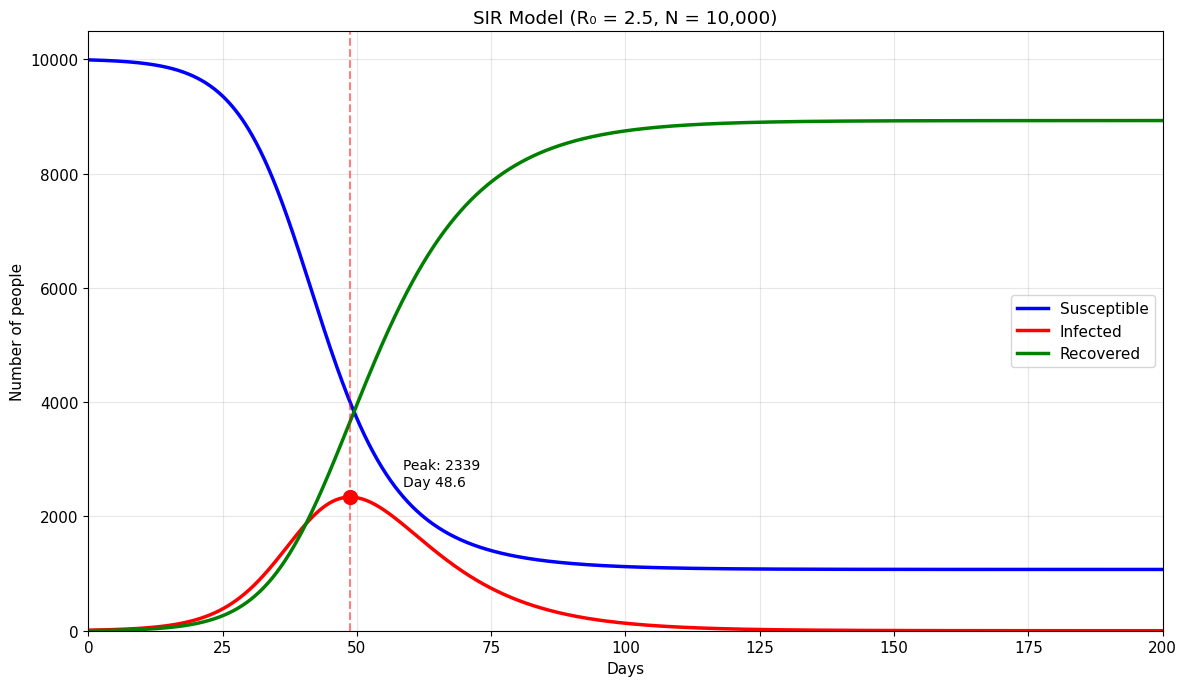

In [6]:
# Main SIR plot

def plot_sir(t, S, I, R, title="SIR Model"):
    """Plot S, I, R curves over time."""
    fig, ax = plt.subplots(figsize=(12, 7))
    
    ax.plot(t, S, 'b-', lw=2.5, label='Susceptible')
    ax.plot(t, I, 'r-', lw=2.5, label='Infected')
    ax.plot(t, R, 'g-', lw=2.5, label='Recovered')
    
    # Mark the peak
    peak_idx = np.argmax(I)
    ax.axvline(t[peak_idx], color='red', ls='--', alpha=0.5)
    ax.scatter([t[peak_idx]], [I[peak_idx]], color='red', s=100, zorder=5)
    ax.annotate(f'Peak: {I[peak_idx]:.0f}\nDay {t[peak_idx]:.1f}',
                xy=(t[peak_idx], I[peak_idx]),
                xytext=(t[peak_idx] + 10, I[peak_idx] + 200),
                fontsize=10)
    
    ax.set_xlabel('Days')
    ax.set_ylabel('Number of people')
    ax.set_title(title)
    ax.legend(loc='right')
    ax.set_xlim(0, t[-1])
    ax.set_ylim(0, None)
    
    plt.tight_layout()
    plt.show()


# Run and plot
N = 10000
I0 = 10
S0 = N - I0
beta = 0.25
gamma = 0.1
R0_val = get_R0(beta, gamma)

t, S, I, R = run_sir_simulation(S0, I0, 0, beta, gamma, 200)
plot_sir(t, S, I, R, title=f'SIR Model (R₀ = {R0_val}, N = {N:,})')

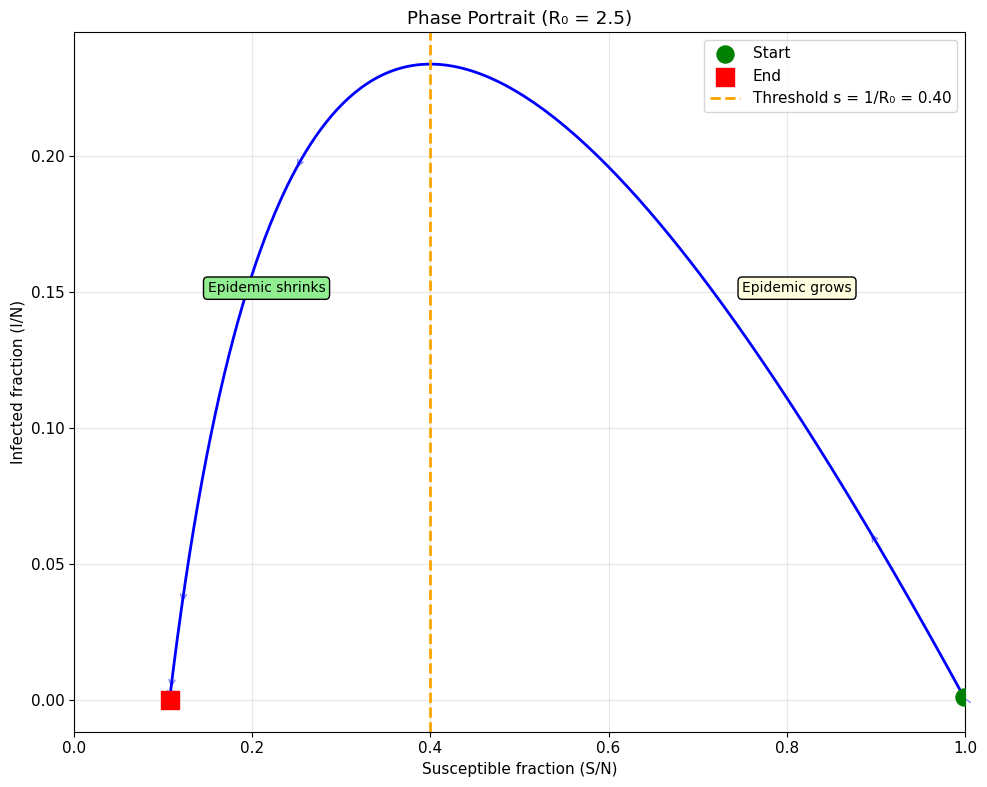

In [7]:
# Phase portrait - shows trajectory in S-I space

def plot_phase(S, I, N, R0_val):
    """Plot I vs S (phase portrait)."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Main trajectory
    ax.plot(S/N, I/N, 'b-', lw=2)
    ax.scatter([S[0]/N], [I[0]/N], color='green', s=150, zorder=5, label='Start')
    ax.scatter([S[-1]/N], [I[-1]/N], color='red', s=150, zorder=5, label='End', marker='s')
    
    # Threshold line
    s_threshold = 1/R0_val
    ax.axvline(s_threshold, color='orange', ls='--', lw=2,
               label=f'Threshold s = 1/R₀ = {s_threshold:.2f}')
    
    # Direction arrows
    for i in np.linspace(0, len(S)-2, 8, dtype=int):
        ax.annotate('', xy=(S[i+1]/N, I[i+1]/N), xytext=(S[i]/N, I[i]/N),
                   arrowprops=dict(arrowstyle='->', color='blue', alpha=0.5))
    
    ax.set_xlabel('Susceptible fraction (S/N)')
    ax.set_ylabel('Infected fraction (I/N)')
    ax.set_title(f'Phase Portrait (R₀ = {R0_val})')
    ax.legend()
    ax.set_xlim(0, 1)
    
    # Add text annotations
    ax.text(0.75, 0.15, 'Epidemic grows', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='lightyellow'))
    ax.text(0.15, 0.15, 'Epidemic shrinks', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightgreen'))
    
    plt.tight_layout()
    plt.show()


plot_phase(S, I, N, R0_val)

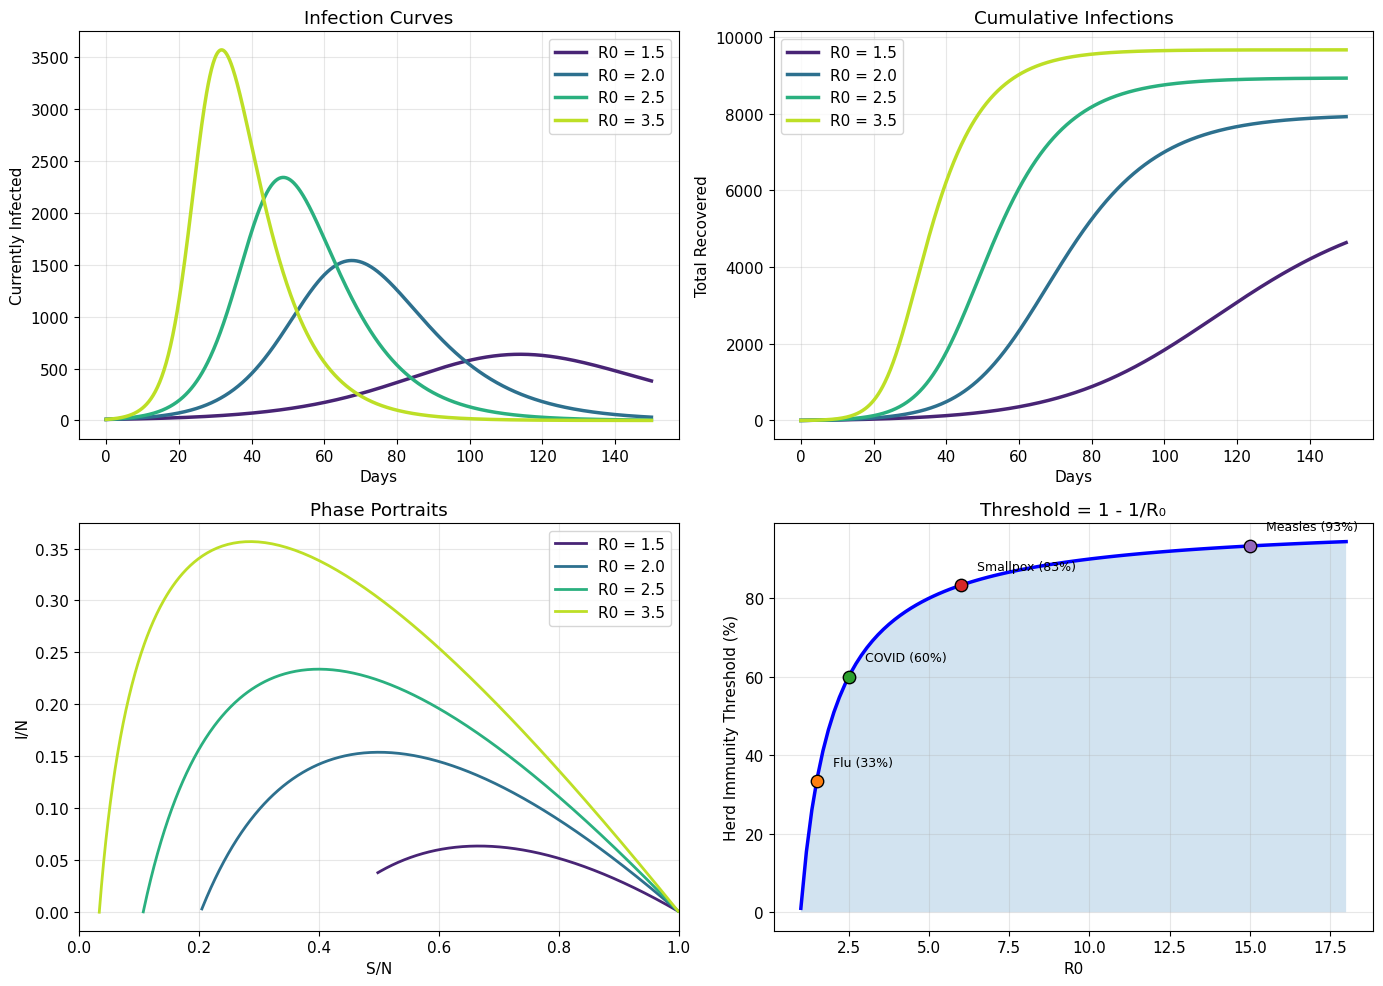


Results for different R₀:

R₀           Peak   Peak Day  Attack Rate

1.5           637      114.0        46.4%
2.0          1539       67.6        79.2%
2.5          2339       48.8        89.2%
3.5          3566       31.7        96.6%


In [8]:
# Compare different R₀ values

def compare_R0s(R0_list, N=10000, I0=10, days=150):
    """Show how different R₀ values affect the epidemic."""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    gamma = 0.1
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(R0_list)))
    
    all_results = []
    
    for R0_target, color in zip(R0_list, colors):
        beta = R0_target * gamma
        S0 = N - I0
        
        t, S, I, R = run_sir_simulation(S0, I0, 0, beta, gamma, days)
        all_results.append((R0_target, t, S, I, R))
        
        # Infection curves
        axes[0, 0].plot(t, I, color=color, lw=2.5, label=f'R0 = {R0_target}')
        
        # Cumulative
        axes[0, 1].plot(t, R, color=color, lw=2.5, label=f'R0 = {R0_target}')
        
        # Phase
        axes[1, 0].plot(S/N, I/N, color=color, lw=2, label=f'R0 = {R0_target}')
    
    axes[0, 0].set_xlabel('Days')
    axes[0, 0].set_ylabel('Currently Infected')
    axes[0, 0].set_title('Infection Curves')
    axes[0, 0].legend()
    
    axes[0, 1].set_xlabel('Days')
    axes[0, 1].set_ylabel('Total Recovered')
    axes[0, 1].set_title('Cumulative Infections')
    axes[0, 1].legend()
    
    axes[1, 0].set_xlabel('S/N')
    axes[1, 0].set_ylabel('I/N')
    axes[1, 0].set_title('Phase Portraits')
    axes[1, 0].legend()
    axes[1, 0].set_xlim(0, 1)
    
    # Herd immunity threshold plot
    R0_range = np.linspace(1.01, 18, 100)
    thresholds = [(1 - 1/r) * 100 for r in R0_range]
    
    axes[1, 1].plot(R0_range, thresholds, 'b-', lw=2.5)
    axes[1, 1].fill_between(R0_range, thresholds, alpha=0.2)
    axes[1, 1].set_xlabel('R0')
    axes[1, 1].set_ylabel('Herd Immunity Threshold (%)')
    axes[1, 1].set_title('Threshold = 1 - 1/R₀')
    
    # Mark some diseases
    diseases = {'Flu': 1.5, 'COVID': 2.5, 'Smallpox': 6, 'Measles': 15}
    for name, r0 in diseases.items():
        thr = (1 - 1/r0) * 100
        axes[1, 1].scatter([r0], [thr], s=80, zorder=5, edgecolors='black')
        axes[1, 1].annotate(f'{name} ({thr:.0f}%)', xy=(r0, thr),
                           xytext=(r0+0.5, thr+4), fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print stats
    print("\nResults for different R₀:")
    print()
    print(f"{'R₀':<6} {'Peak':>10} {'Peak Day':>10} {'Attack Rate':>12}")
    print()
    for R0_target, t, S, I, R in all_results:
        print(f"{R0_target:<6.1f} {max(I):>10.0f} {t[np.argmax(I)]:>10.1f} {R[-1]/N*100:>11.1f}%")


compare_R0s([1.5, 2.0, 2.5, 3.5])

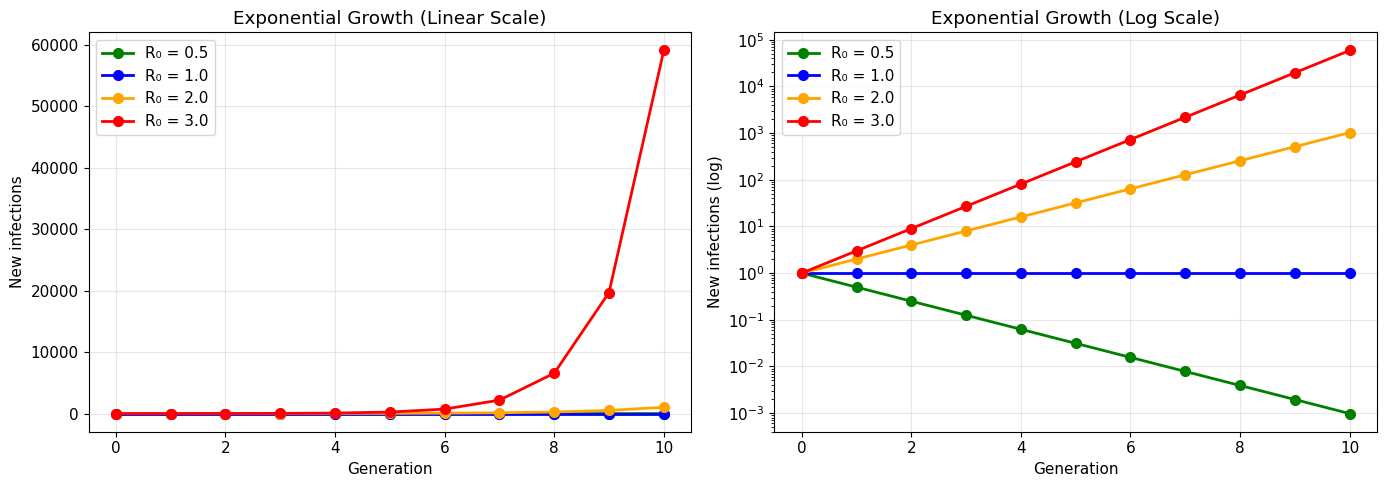


R₀ = 2.0: 33 generations
R₀ = 2.5: 25 generations
R₀ = 3.0: 21 generations


In [9]:
# Exponential growth visualization

def show_exponential_growth(R0_list=[0.5, 1.0, 2.0, 3.0], generations=10):
    """Show how R0 affects exponential growth."""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = ['green', 'blue', 'orange', 'red']
    
    for R0, color in zip(R0_list, colors):
        gens = np.arange(0, generations + 1)
        infections = R0 ** gens
        
        axes[0].plot(gens, infections, 'o-', lw=2, ms=7, label=f'R₀ = {R0}', color=color)
        axes[1].semilogy(gens, infections, 'o-', lw=2, ms=7, label=f'R₀ = {R0}', color=color)
    
    axes[0].set_xlabel('Generation')
    axes[0].set_ylabel('New infections')
    axes[0].set_title('Exponential Growth (Linear Scale)')
    axes[0].legend()
    
    axes[1].set_xlabel('Generation')
    axes[1].set_ylabel('New infections (log)')
    axes[1].set_title('Exponential Growth (Log Scale)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

    print()
    world = 7.8e9
    for R0 in [2.0, 2.5, 3.0]:
        n = np.log(world) / np.log(R0)
        print(f"R₀ = {R0}: {n:.0f} generations")


show_exponential_growth()

## 9. Vaccination Effects

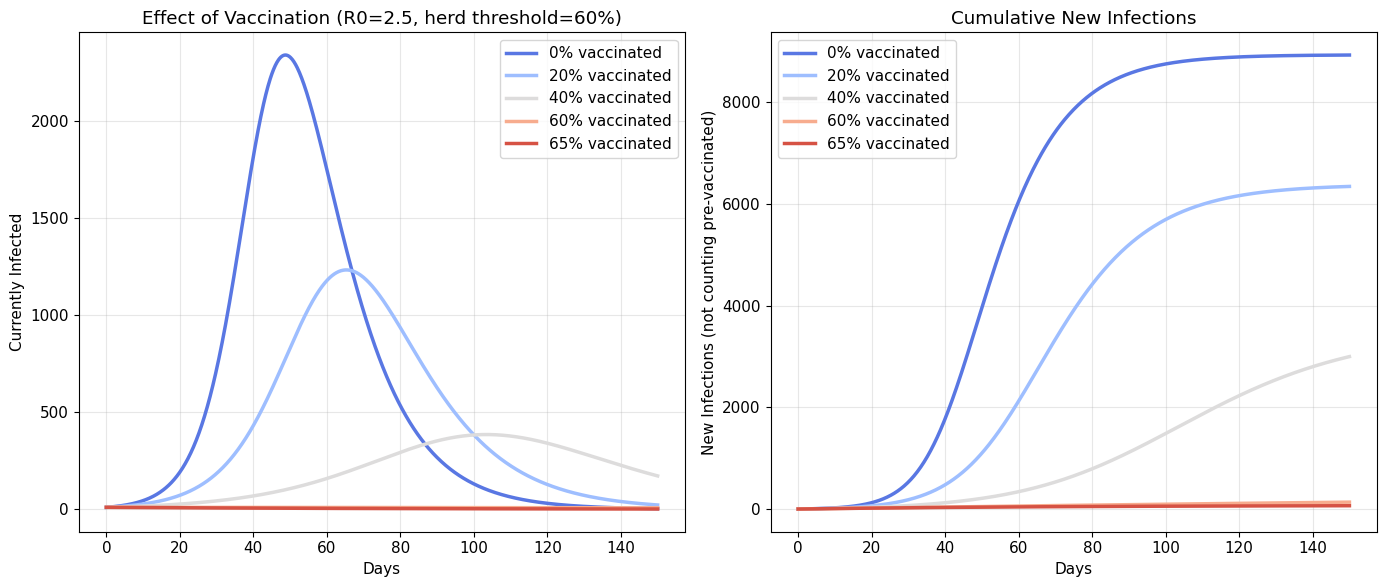


R₀ = 2.5, Herd threshold = 60%

Vax Rate           Peak Total New Infections

       0%       2339                 8923
      20%       1232                 6341
      40%        385                 2996
      60%         10                  135
      65%         10                   65


In [10]:
# Effect of pre-vaccination

def show_vaccination_effect(N=10000, I0=10, R0_target=2.5, vax_levels=[0, 0.2, 0.4, 0.6], days=150):
    """
    Let me show you what happens with different vaccination levels.
    Vaccinated people start in R compartment (already immune).
    """
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    gamma = 0.1
    beta = R0_target * gamma
    herd = get_herd_threshold(R0_target)
    
    colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(vax_levels)))
    
    results = []
    
    for vax, color in zip(vax_levels, colors):
        # Vaccinated start in R
        R0_init = int(N * vax)
        S0 = N - I0 - R0_init
        
        t, S, I, R = run_sir_simulation(S0, I0, R0_init, beta, gamma, days)
        
        label = f'{vax*100:.0f}% vaccinated'
        axes[0].plot(t, I, color=color, lw=2.5, label=label)
        axes[1].plot(t, R - R0_init, color=color, lw=2.5, label=label)  # New infections only
        
        results.append((vax, max(I), R[-1] - R0_init))
    
    axes[0].set_xlabel('Days')
    axes[0].set_ylabel('Currently Infected')
    axes[0].set_title(f'Effect of Vaccination (R0={R0_target}, herd threshold={herd*100:.0f}%)')
    axes[0].legend()
    
    axes[1].set_xlabel('Days')
    axes[1].set_ylabel('New Infections (not counting pre-vaccinated)')
    axes[1].set_title('Cumulative New Infections')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nR₀ = {R0_target}, Herd threshold = {herd*100:.0f}%")
    print()
    print(f"{'Vax Rate':<12} {'Peak':>10} {'Total New Infections':>20}")
    print()
    for vax, peak, total in results:
        print(f"{vax*100:>8.0f}% {peak:>10.0f} {total:>20.0f}")


show_vaccination_effect(vax_levels=[0, 0.2, 0.4, 0.6, 0.65])

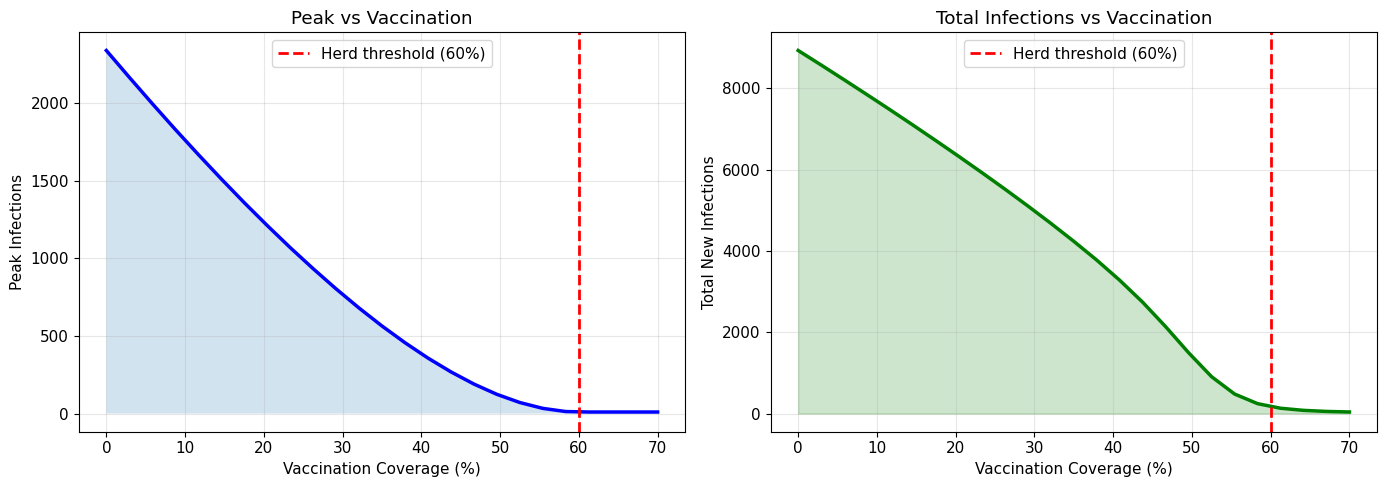

In [11]:
# How outcomes change as we approach the threshold

def vaccination_threshold_analysis(R0_target=2.5, N=10000, I0=10, days=200):
    """Let's see how epidemic changes as vaccination approaches threshold."""
    
    gamma = 0.1
    beta = R0_target * gamma
    herd = get_herd_threshold(R0_target)
    
    vax_levels = np.linspace(0, herd + 0.1, 25)
    peaks = []
    totals = []
    
    for vax in vax_levels:
        R0_init = int(N * vax)
        S0 = N - I0 - R0_init
        
        t, S, I, R = run_sir_simulation(S0, I0, R0_init, beta, gamma, days)
        peaks.append(max(I))
        totals.append(R[-1] - R0_init)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Peak vs vaccination
    axes[0].plot(vax_levels * 100, peaks, 'b-', lw=2.5)
    axes[0].axvline(herd * 100, color='red', ls='--', lw=2, 
                   label=f'Herd threshold ({herd*100:.0f}%)')
    axes[0].fill_between(vax_levels * 100, peaks, alpha=0.2)
    axes[0].set_xlabel('Vaccination Coverage (%)')
    axes[0].set_ylabel('Peak Infections')
    axes[0].set_title('Peak vs Vaccination')
    axes[0].legend()
    
    # Total vs vaccination
    axes[1].plot(vax_levels * 100, totals, 'g-', lw=2.5)
    axes[1].axvline(herd * 100, color='red', ls='--', lw=2,
                   label=f'Herd threshold ({herd*100:.0f}%)')
    axes[1].fill_between(vax_levels * 100, totals, alpha=0.2, color='green')
    axes[1].set_xlabel('Vaccination Coverage (%)')
    axes[1].set_ylabel('Total New Infections')
    axes[1].set_title('Total Infections vs Vaccination')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()


vaccination_threshold_analysis()

---

## Parameter Sensitivity and Real-World Challenges

### Why This Matters

So far, we've treated β and γ as known constants. In reality, these parameters are **estimated** from noisy, incomplete data, and getting them wrong has consequences. There are two fundamental challenges when applying the SIR model to real epidemics:

1. **Random noise (stochasticity)**: Real epidemics involve discrete individuals making random contacts, not smooth differential equations. Small populations or early-stage outbreaks can behave very differently from the deterministic model.

2. **Parameter misestimation**: If you underestimate β (transmission rate) or overestimate γ (recovery rate), your model will predict a milder epidemic than what actually happens. This is dangerous by the way for policy decisions.

Let's explore both of these systematically.

## 10. Limitations

### What the Model Gets Wrong

The SIR model is useful, but it's definitely simplified.

| Assumption | Reality | Why it matters |
|-----------|---------|-----------------------------------------------|
| Everyone mixes equally | People have different contact patterns (work, family, etc.) | Model overestimates spread in sparse networks |
| Fixed β and γ | Behavior changes (masks, distancing), seasons affect transmission | Miss dynamic changes during epidemic          |
| No births/deaths | People are born, die from other causes | Only good for short epidemics                 |
| Permanent immunity | Some diseases allow reinfection | Underestimates long-term burden               |
| No incubation | Many diseases have latent period | SEIR model handles this better                |

### Extensions That Address These

Real epidemiologists use more complex models:
Like **SEIR** -  Adds 'Exposed' compartment for latent period, **SIRS** -  Allows immunity to wear off, **Network models** - Actual contact patterns between people, and many other models.

### What the Model Gets Right

Despite the simplifications, SIR captures the essentials:

1. The threshold behavior (R₀ > 1 for epidemic) is real
2. The herd immunity formula is approximately correct
3. The qualitative dynamics (rise, peak, fall) match observations
4. It's a good starting point for building intuition

## 11. Conclusion

### What I Learned

Working through this project, I got a much better understanding of:

1. **The SIR model** - It's basically just three differential equations, but they capture the essence of how epidemics work. The mass action term (βSI/N) is the key insight.

2. **R₀** - This number answers "how many people does one sick person infect?" If it's above 1, you get exponential growth. The formula R₀ = β/γ makes sense.

3. **Herd immunity** - The threshold formula p = 1 - 1/R₀ is elegant. For COVID with R₀ around 2.5, you need ~60% immunity.

4. **Numerical methods** - Euler's method is simple but works. That is why most of the time simple things work better than the something that is more complicated.

5. **Vaccination** - The simulations show clearly that vaccinating up to the herd immunity threshold makes a huge difference. Getting from 40% to 60% coverage reduces peak infections dramatically.

### Real-World Applications

These models (and more sophisticated versions) are used for, setting vaccination targets, allocating hospital resources, and more.

### What I'd Do Next

If I had more time, I'd want to:
- Implement SEIR to handle incubation periods
- Add stochastic effects for small population modeling

## 12. References

### Main Sources

[1] Freiberger, M. (2020). "Maths in a minute: R nought and herd immunity." Plus Magazine.  
https://plus.maths.org/content/maths-minute-r0-and-herd-immunity

[2] Kwok, K.O., et al. (2021). "Herd immunity – estimating the level required to halt the COVID-19 epidemics." Journal of Infection.  
https://pmc.ncbi.nlm.nih.gov/articles/PMC7880839/

[3] Fine, P., Eames, K., & Heymann, D.L. (2011). "Herd Immunity: A Rough Guide." Clinical Infectious Diseases.  
https://pmc.ncbi.nlm.nih.gov/articles/PMC6002118/

[4] College of Physicians of Philadelphia. "How Herd Immunity Works." History of Vaccines.  
https://historyofvaccines.org/vaccines-101/how-herd-immunity-works/

[5] Wikipedia. "Compartmental models (epidemiology)."  
https://en.wikipedia.org/wiki/Compartmental_models_(epidemiology)

[6] Wikipedia. "Basic reproduction number."  
https://en.wikipedia.org/wiki/Basic_reproduction_number

[7] Wikipedia (German). "SIR-Modell."  
https://de.wikipedia.org/wiki/SIR-Modell

[8] Universitat Autònoma de Barcelona. "SIR Model Analysis."  
https://mat.uab.cat/matmat_antiga/PDFv2013/v2013n03.pdf

[9] Wikipedia. "Mathematical modelling of infectious diseases."  
https://en.wikipedia.org/wiki/Mathematical_modelling_of_infectious_diseases

[10] Makhoul, M., et al. (2020). "Epidemiological Impact of SARS-CoV-2 Vaccination." Vaccines.  
https://pmc.ncbi.nlm.nih.gov/articles/PMC8523531/
